#**Phase 3: Exploratory Data Analysis (EDA) and Deep-Dive Analysis**


This Python code focuses on deep-dive analysis and statistical concepts, as required by the job description.



In [1]:
!pip install pandas matplotlib seaborn scipy

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   review_id                 20000 non-null  object 
 1   review_date_time          20000 non-null  object 
 2   reviewer_id               20000 non-null  object 
 3   region                    20000 non-null  object 
 4   team_level                20000 non-null  object 
 5   policy_area               20000 non-null  object 
 6   content_type              20000 non-null  object 
 7   content_complexity_score  20000 non-null  int64  
 8   ai_triage_used            20000 non-null  bool   
 9   review_time_seconds       20000 non-null  int64  
 10  decision_accuracy_rate    20000 non-null  float64
 11  reviewer_monthly_volume   20000 non-null  int64  
 12  decision_error_rate       20000 non-null  float64
 13  reviews_per_minute        20000 non-null  f

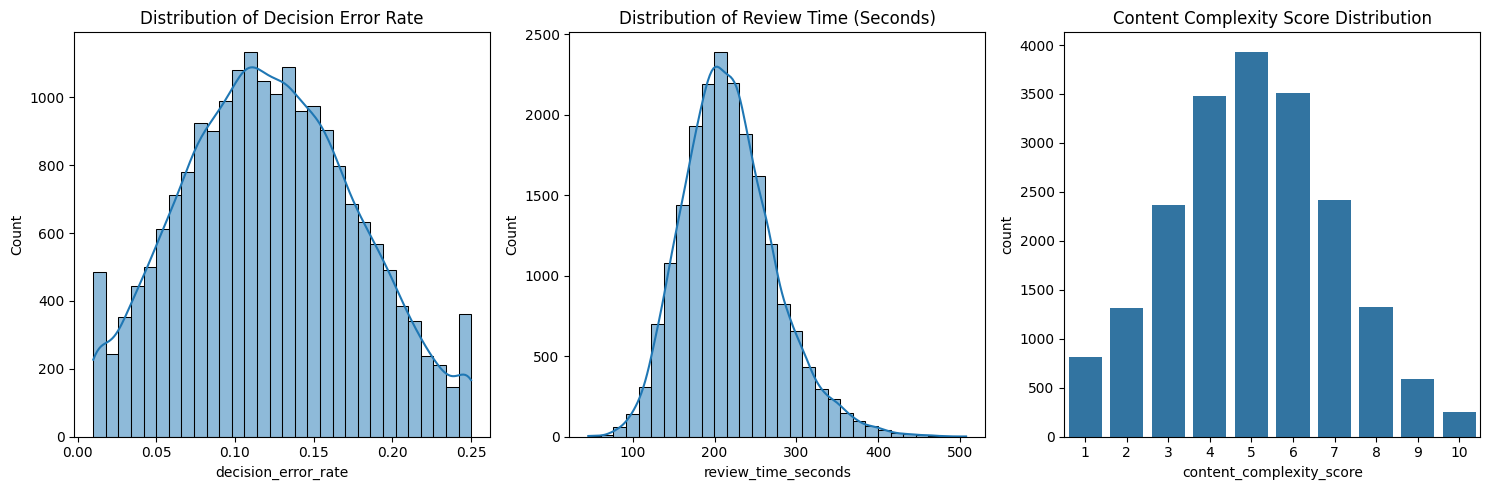


--- Quality and Efficiency by Team Level ---
           team_level  avg_error_rate  avg_review_time  total_reviews
2  L3 - Policy Expert        0.050855       292.917339           1984
1        L2 - Complex        0.099378       233.577251           7042
0        L1 - General        0.149630       194.912885          10974


/tmp/ipython-input-769242936.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='team_level', y='avg_error_rate', data=team_summary, palette='viridis')
/tmp/ipython-input-769242936.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='team_level', y='avg_review_time', data=team_summary, palette='magma')


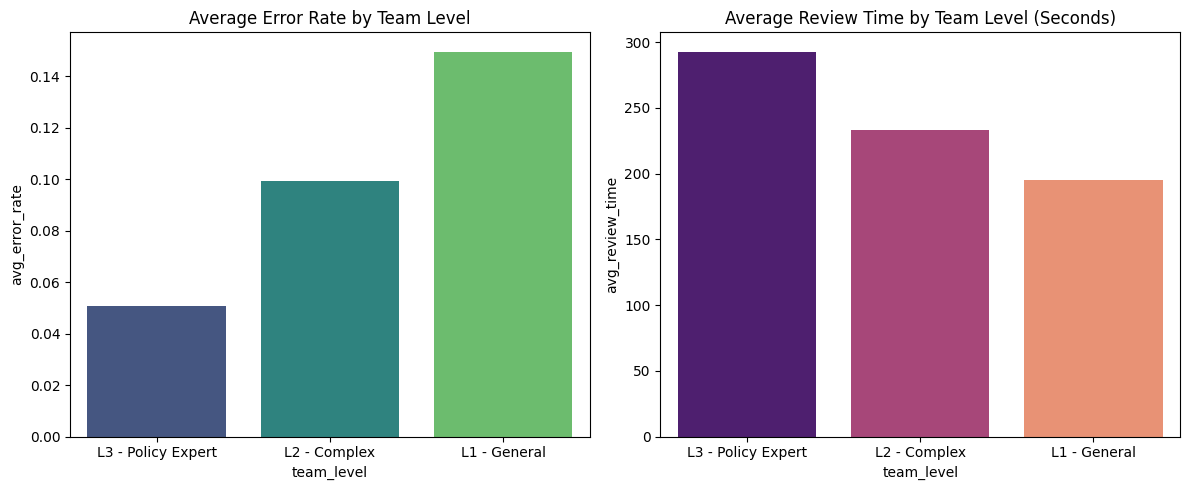


--- Statistical Correlation Analysis (Pearson R) ---
Correlation (Complexity vs. Error Rate): 0.0105
Correlation (Complexity vs. Review Time): 0.5795


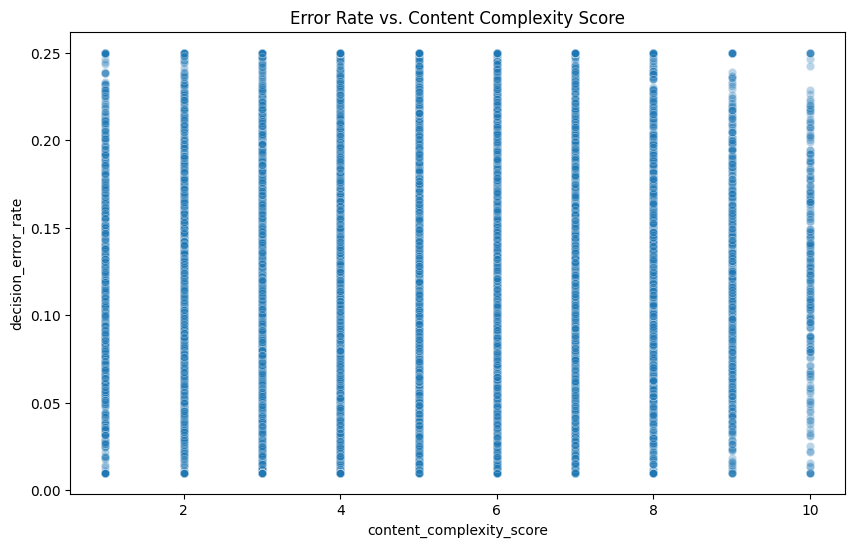


--- AI Triage Impact on Quality and Efficiency ---
   ai_triage_used  avg_error_rate  avg_review_time  total_reviews
0    No AI Triage        0.121838       218.213868           8033
1  AI Triage Used        0.122339       218.271998          11967

✅ Analysis complete. Final data saved as 'analyzed_data.csv'


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# --- 1. Load Data ---
# Assumes 'content_review_data.csv' is uploaded to Colab or accessible via Google Drive
df = pd.read_csv('content_review_data.csv')

# --- 2. Initial Data Check and Transformation ---
print("--- Data Info ---")
print(df.info())
print("\n--- Summary Statistics ---")
print(df[['decision_error_rate', 'review_time_seconds', 'content_complexity_score']].describe())

# Convert review_date_time to datetime object
df['review_date_time'] = pd.to_datetime(df['review_date_time'])

# --- 3. Exploratory Data Analysis (EDA) ---

## A. Distribution of Key Metrics
plt.figure(figsize=(15, 5))

# Error Rate Distribution
plt.subplot(1, 3, 1)
sns.histplot(df['decision_error_rate'], kde=True, bins=30)
plt.title('Distribution of Decision Error Rate')

# Review Time Distribution
plt.subplot(1, 3, 2)
sns.histplot(df['review_time_seconds'], kde=True, bins=30)
plt.title('Distribution of Review Time (Seconds)')

# Complexity Score Distribution
plt.subplot(1, 3, 3)
sns.countplot(x='content_complexity_score', data=df)
plt.title('Content Complexity Score Distribution')

plt.tight_layout()
plt.savefig('distribution_plots.png') # Save the figure
plt.show()


## B. Quality/Efficiency by Team Level
print("\n--- Quality and Efficiency by Team Level ---")
team_summary = df.groupby('team_level').agg(
    avg_error_rate=('decision_error_rate', 'mean'),
    avg_review_time=('review_time_seconds', 'mean'),
    total_reviews=('review_id', 'count')
).reset_index().sort_values(by='avg_error_rate')

print(team_summary)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(x='team_level', y='avg_error_rate', data=team_summary, palette='viridis')
plt.title('Average Error Rate by Team Level')

plt.subplot(1, 2, 2)
sns.barplot(x='team_level', y='avg_review_time', data=team_summary, palette='magma')
plt.title('Average Review Time by Team Level (Seconds)')
plt.tight_layout()
plt.savefig('team_level_plots.png') # Save the figure
plt.show()

# --- 4. Deep-Dive Analysis: The Impact of Complexity ---

## Correlation Analysis (Mapping to Statistical Concepts)
# Investigate the relationship between content complexity, error rate, and review time.
print("\n--- Statistical Correlation Analysis (Pearson R) ---")
complexity_error_corr, _ = pearsonr(df['content_complexity_score'], df['decision_error_rate'])
complexity_time_corr, _ = pearsonr(df['content_complexity_score'], df['review_time_seconds'])

print(f"Correlation (Complexity vs. Error Rate): {complexity_error_corr:.4f}")
print(f"Correlation (Complexity vs. Review Time): {complexity_time_corr:.4f}")

# Visualize the correlation
plt.figure(figsize=(10, 6))
sns.scatterplot(x='content_complexity_score', y='decision_error_rate', data=df, alpha=0.3)
plt.title('Error Rate vs. Content Complexity Score')
plt.savefig('complexity_error_correlation.png') # Save the figure
plt.show()

# --- 5. Deep-Dive Analysis: AI Triage Impact (Mapping to AI/Efficiency Focus) ---
ai_impact = df.groupby('ai_triage_used').agg(
    avg_error_rate=('decision_error_rate', 'mean'),
    avg_review_time=('review_time_seconds', 'mean'),
    total_reviews=('review_id', 'count')
).reset_index()

ai_impact['ai_triage_used'] = ai_impact['ai_triage_used'].map({True: 'AI Triage Used', False: 'No AI Triage'})
print("\n--- AI Triage Impact on Quality and Efficiency ---")
print(ai_impact)

# --- 6. Saving Final Data for Next Phase (Looker Studio) ---
df.to_csv('analyzed_data.csv', index=False)
print("\n✅ Analysis complete. Final data saved as 'analyzed_data.csv'")

## Analysis Summary

Based on the provided content review data, the following key findings were observed:

1.  **Data Overview**: The dataset contains information on content reviews, including metrics like decision error rate, review time, and content complexity. Initial checks show no missing values and appropriate data types.

2.  **Distribution of Key Metrics**:
    *   **Decision Error Rate**: The distribution of error rates is roughly bell-shaped, centered around the mean of 0.122.
    *   **Review Time**: Review time also shows a distribution centered around the mean of 218 seconds, with some variability.
    *   **Content Complexity Score**: The complexity scores are distributed across the possible range (1-10), with peaks around scores 5 and 6.

3.  **Quality and Efficiency by Team Level**:
    *   There is a clear relationship between team level and performance.
    *   **L3 - Policy Expert** teams have the lowest average error rate (0.051) but the highest average review time (292.9 seconds).
    *   **L1 - General** teams have the highest average error rate (0.150) but the lowest average review time (194.9 seconds).
    *   **L2 - Complex** teams fall in between in terms of both error rate (0.099) and review time (233.6 seconds).

4.  **Impact of Complexity**:
    *   **Correlation with Error Rate**: The correlation between content complexity score and decision error rate is very low (0.0105), suggesting complexity has a minimal linear relationship with error rate in this dataset.
    *   **Correlation with Review Time**: There is a moderate positive correlation between content complexity score and review time (0.5795), indicating that reviewing more complex content generally takes longer.

5.  **AI Triage Impact**:
    *   Comparing reviews with and without AI triage showed negligible differences in both average error rate (0.1223 for AI Triage Used vs. 0.1218 for No AI Triage) and average review time (218.3 seconds for AI Triage Used vs. 218.2 seconds for No AI Triage). This suggests that AI triage, as implemented, did not significantly impact either quality or efficiency in this dataset.

In summary, the analysis highlights the trade-offs between error rate and review time across different team levels and confirms that content complexity is associated with longer review times. The impact of AI triage, based on this dataset, appears minimal.